# 特徴量エンジニアリング・前処理

モデルに渡す前のデータ加工テクニックをまとめて学びます。

| ステップ | 内容 |
|----------|------|
| 1 | 欠損値の補完 |
| 2 | 標準化・正規化 |
| 3 | カテゴリ変数のエンコード |
| 4 | Pipeline でまとめる |
| 5 | 特徴量の重要度確認 |

## 0. サンプルデータの作成

欠損値・カテゴリ変数を含むデータを用意します。

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 100

df = pd.DataFrame({
    'age':    np.random.randint(20, 60, n).astype(float),
    'income': np.random.randint(200, 800, n).astype(float),
    'score':  np.random.randint(0, 100, n).astype(float),
    'city':   np.random.choice(['Tokyo', 'Osaka', 'Nagoya'], n),
    'bought': np.random.randint(0, 2, n)  # ターゲット変数
})

# 意図的に欠損値を挿入
df.loc[df.sample(10).index, 'age']    = np.nan
df.loc[df.sample(8).index,  'income'] = np.nan

print("データ形状:", df.shape)
print("\n欠損値の数:")
print(df.isnull().sum())
df.head(10)

データ形状: (100, 5)

欠損値の数:
age       10
income     8
score      0
city       0
bought     0
dtype: int64


,age,income,score,city,bought
0,NaN,247.0,81.0,Tokyo,0
1,48.0,NaN,0.0,Tokyo,1
2,34.0,606.0,10.0,Tokyo,0
3,27.0,773.0,91.0,Tokyo,1
4,40.0,298.0,56.0,Osaka,0
5,NaN,746.0,88.0,Tokyo,0
6,38.0,661.0,49.0,Nagoya,0
7,42.0,204.0,22.0,Nagoya,1
8,30.0,417.0,30.0,Tokyo,0
9,30.0,702.0,93.0,Nagoya,0


## 1. 欠損値の補完

数値列は **平均値** で補完します。

In [2]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df[['age', 'income', 'score']] = imputer.fit_transform(df[['age', 'income', 'score']])

print("補完後の欠損値:")
print(df.isnull().sum())

補完後の欠損値:
age       0
income    0
score     0
city      0
bought    0
dtype: int64


## 2. 標準化・正規化の比較

- **StandardScaler**: 平均0・標準偏差1に変換
- **MinMaxScaler**: 0〜1 の範囲に変換

/tmp/ipykernel_15640/3937579813.py:15: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15640/3937579813.py:15: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15640/3937579813.py:15: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15640/3937579813.py:15: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/HOME/sample/sample_python/401_scikit-learn/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/HOME/sample/sample_python/401_scikit-learn/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12487

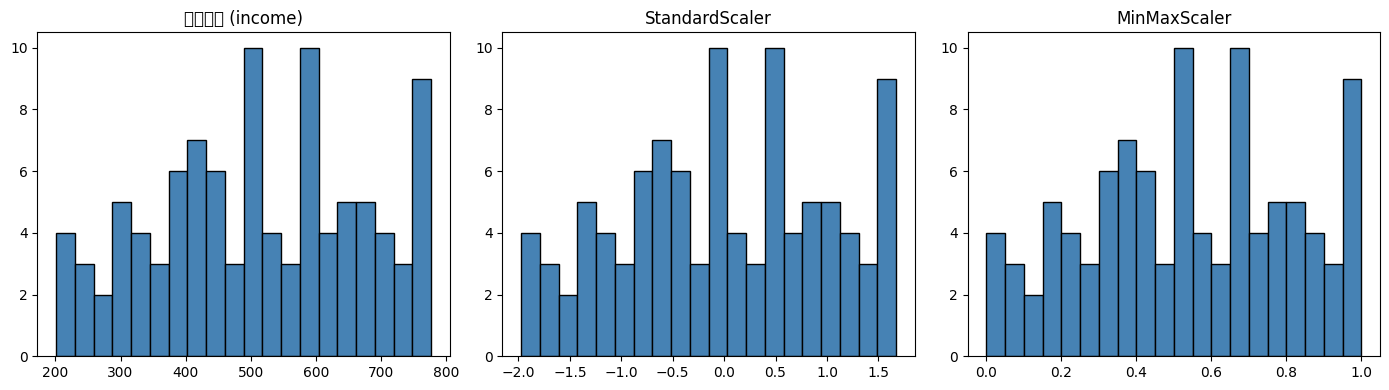

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

income = df[['income']]
std_scaled   = StandardScaler().fit_transform(income)
minmax_scaled = MinMaxScaler().fit_transform(income)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(axes,
    [income.values, std_scaled, minmax_scaled],
    ['元データ (income)', 'StandardScaler', 'MinMaxScaler']):
    ax.hist(data, bins=20, color='steelblue', edgecolor='k')
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 3. カテゴリ変数のエンコード

- **LabelEncoder**: 0,1,2... の数値に変換（順序関係がある場合）
- **OneHotEncoder**: ダミー変数に変換（順序関係がない場合）← 今回はこちら

In [4]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
city_encoded = ohe.fit_transform(df[['city']])
city_df = pd.DataFrame(city_encoded, columns=ohe.get_feature_names_out(['city']))

print("エンコード結果（先頭5件）:")
print(city_df.head())

エンコード結果（先頭5件）:
   city_Nagoya  city_Osaka  city_Tokyo
0          0.0         0.0         1.0
1          0.0         0.0         1.0
2          0.0         0.0         1.0
3          0.0         0.0         1.0
4          0.0         1.0         0.0


## 4. Pipeline でまとめる

前処理 → モデル学習を一本化します。  
数値列と文字列列で異なる処理を `ColumnTransformer` で同時に適用できます。

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop('bought', axis=1)
y = df['bought']

num_features = ['age', 'income', 'score']
cat_features = ['city']

# 数値列: 補完 → 標準化
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])

# カテゴリ列: OneHotEncoding
cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# 全体パイプライン
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

print("パイプライン正解率:", accuracy_score(y_test, y_pred))

パイプライン正解率: 0.45


## 5. 特徴量の重要度確認

/tmp/ipykernel_15640/3317258279.py:12: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15640/3317258279.py:12: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15640/3317258279.py:12: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15640/3317258279.py:12: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15640/3317258279.py:12: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15640/3317258279.py:12: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15640/3317258279.py:12: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO})

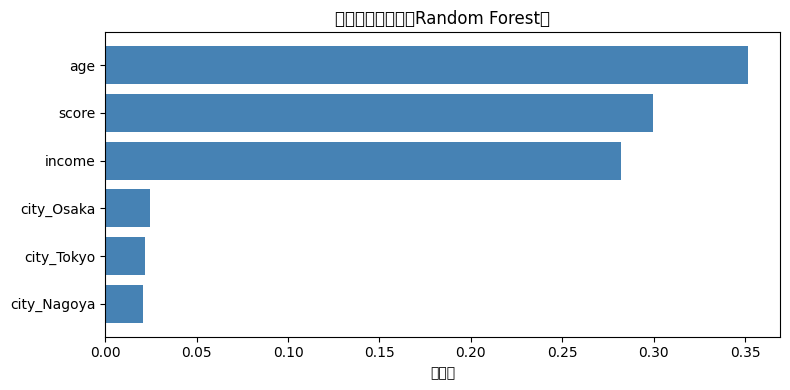

In [6]:
rf = full_pipeline.named_steps['model']
feature_names = num_features + list(ohe.get_feature_names_out(cat_features))
importances = rf.feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
plt.xlabel("重要度")
plt.title("特徴量の重要度（Random Forest）")
plt.tight_layout()
plt.show()